# 🖼️ Image Classification with a CNN — PyTorch on CIFAR-10

This notebook walks you through the **complete deep learning pipeline**:

1. Load & explore a dataset  
2. Preprocess & augment images  
3. Build a Convolutional Neural Network (CNN)  
4. Train the model  
5. Evaluate on test data  
6. Visualize predictions  

**Dataset:** CIFAR-10 — 60,000 colour images (32×32) across 10 classes  
**Framework:** PyTorch  

> 💡 **Tip:** Go to `Runtime → Change runtime type → GPU` before running.

## 1. Imports & Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Load & Explore the Dataset

We apply two sets of transforms:
- **Train:** random flip + crop for data augmentation (helps the model generalise)
- **Test:** just normalise (no augmentation — we want a fair evaluation)

In [2]:
# CIFAR-10 mean and std (pre-computed across the training set)
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),          # randomly mirror images
    transforms.RandomCrop(32, padding=4),       # randomly shift/crop
    transforms.ToTensor(),                      # convert PIL image → tensor [0,1]
    transforms.Normalize(MEAN, STD),            # normalise to ~N(0,1)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Download dataset (only on first run)
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                              download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=test_transform)

# DataLoaders — batches of 64 images at a time
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64,
                                            shuffle=True,  num_workers=2)
test_loader  = torch.utils.data.DataLoader(test_dataset,  batch_size=64,
                                            shuffle=False, num_workers=2)

CLASSES = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')
print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')

100%|██████████| 170M/170M [00:04<00:00, 42.5MB/s]


Training samples : 50,000
Test samples     : 10,000


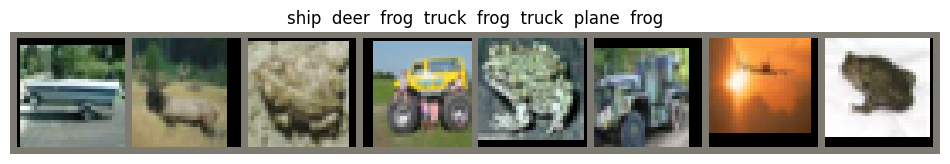

In [3]:
# Visualise a batch of training images
def imshow(img):
    """Un-normalise and display a tensor as an image."""
    img = img * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

images, labels = next(iter(train_loader))
plt.figure(figsize=(12, 3))
imshow(torchvision.utils.make_grid(images[:8]))
plt.title('  '.join(CLASSES[labels[i]] for i in range(8)))
plt.show()

## 3. Build the CNN

Our network has two **convolutional blocks** (Conv → BatchNorm → ReLU → MaxPool) followed by a small **fully-connected classifier**.

| Layer | Purpose |
|---|---|
| Conv2d | Detect local patterns (edges, textures) |
| BatchNorm | Stabilise training |
| ReLU | Add non-linearity |
| MaxPool | Reduce spatial size, keep strongest features |
| Linear | Map features → class scores |

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # Block 1: 3 input channels (RGB) → 32 feature maps
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 → 32x32
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 32x32 → 16x16
            nn.Dropout(0.25),
        )

        # Block 2: 32 → 64 feature maps
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 → 16x16
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 16x16 → 8x8
            nn.Dropout(0.25),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),                # 64 × 8 × 8 = 4096
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes), # 10 class scores
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x


model = SimpleCNN().to(device)

# Count trainable parameters
params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model has {params:,} trainable parameters')
print(model)

Model has 2,168,746 trainable parameters
SimpleCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (

## 4. Training Loop

Key ingredients:
- **Loss function:** CrossEntropyLoss — standard for multi-class classification  
- **Optimiser:** Adam with weight decay (L2 regularisation)  
- **LR scheduler:** reduces learning rate when validation loss plateaus

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0.0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n


def evaluate(model, loader, criterion):
    model.eval()  # disables dropout / uses running batch norm stats
    total_loss, correct = 0.0, 0
    with torch.no_grad():  # no gradients needed during evaluation
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()

    n = len(loader.dataset)
    return total_loss / n, correct / n


EPOCHS = 20
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    vl_loss, vl_acc = evaluate(model, test_loader, criterion)
    scheduler.step(vl_loss)

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)

    print(f'Epoch {epoch:2d}/{EPOCHS}  '
          f'Train loss: {tr_loss:.4f}  acc: {tr_acc:.3f}  |  '
          f'Val loss: {vl_loss:.4f}  acc: {vl_acc:.3f}')

Epoch  1/20  Train loss: 1.7391  acc: 0.356  |  Val loss: 1.3162  acc: 0.511
Epoch  2/20  Train loss: 1.4169  acc: 0.481  |  Val loss: 1.1132  acc: 0.601
Epoch  3/20  Train loss: 1.2591  acc: 0.544  |  Val loss: 0.9384  acc: 0.667
Epoch  4/20  Train loss: 1.1656  acc: 0.586  |  Val loss: 0.9025  acc: 0.666
Epoch  5/20  Train loss: 1.1076  acc: 0.609  |  Val loss: 0.8566  acc: 0.692
Epoch  6/20  Train loss: 1.0551  acc: 0.628  |  Val loss: 0.8073  acc: 0.717
Epoch  7/20  Train loss: 1.0155  acc: 0.644  |  Val loss: 0.8338  acc: 0.706
Epoch  8/20  Train loss: 0.9771  acc: 0.657  |  Val loss: 0.7905  acc: 0.719
Epoch  9/20  Train loss: 0.9381  acc: 0.672  |  Val loss: 0.7429  acc: 0.740
Epoch 10/20  Train loss: 0.9051  acc: 0.685  |  Val loss: 0.7515  acc: 0.743
Epoch 11/20  Train loss: 0.8710  acc: 0.701  |  Val loss: 0.6911  acc: 0.757
Epoch 12/20  Train loss: 0.8462  acc: 0.708  |  Val loss: 0.7142  acc: 0.755
Epoch 13/20  Train loss: 0.8126  acc: 0.719  |  Val loss: 0.6793  acc: 0.762

## 5. Training Curves

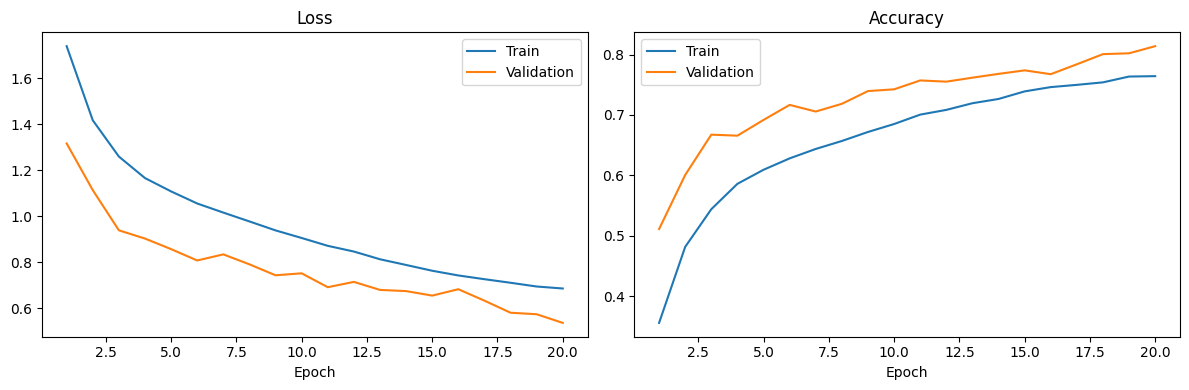


Final test accuracy: 81.4%


In [7]:
epochs = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'],   label='Validation')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(epochs, history['train_acc'], label='Train')
axes[1].plot(epochs, history['val_acc'],   label='Validation')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.tight_layout()
plt.show()

print(f'\nFinal test accuracy: {history["val_acc"][-1]*100:.1f}%')

## 6. Visualise Predictions

Green title = correct prediction, Red = wrong.

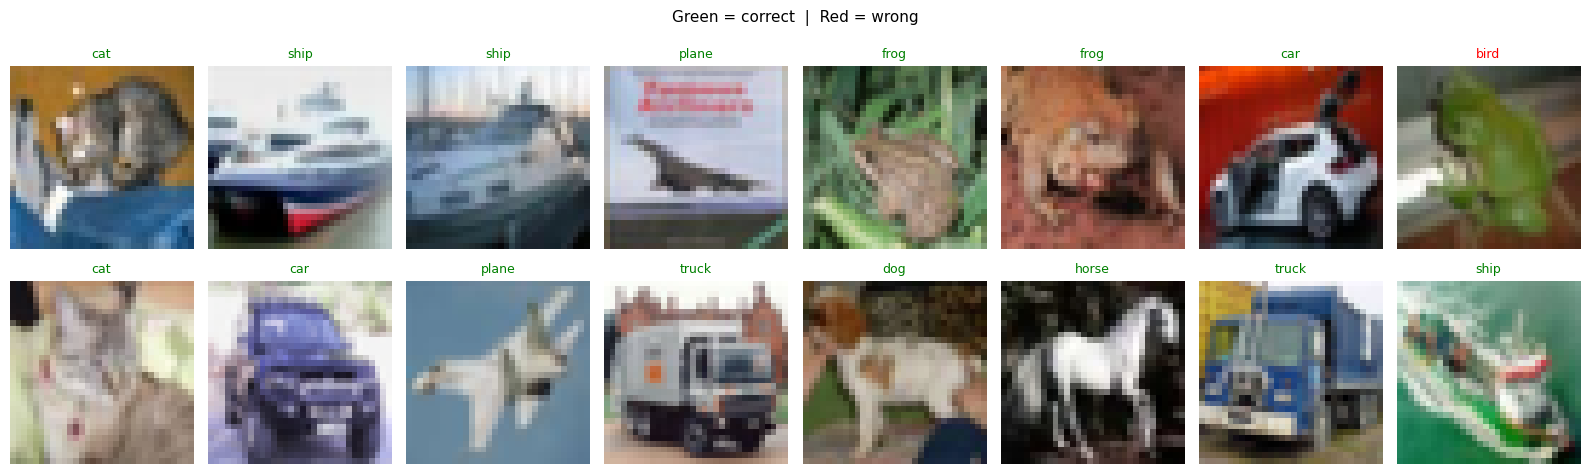

In [8]:
model.eval()
images, labels = next(iter(test_loader))
images_gpu = images[:16].to(device)

with torch.no_grad():
    preds = model(images_gpu).argmax(1).cpu()

fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for i, ax in enumerate(axes.flatten()):
    img = images[i] * torch.tensor(STD).view(3,1,1) + torch.tensor(MEAN).view(3,1,1)
    ax.imshow(img.permute(1, 2, 0).clamp(0, 1))
    ax.axis('off')
    color = 'green' if preds[i] == labels[i] else 'red'
    ax.set_title(f'{CLASSES[preds[i]]}', color=color, fontsize=9)

plt.suptitle('Green = correct  |  Red = wrong', fontsize=11)
plt.tight_layout()
plt.show()

## 7. Per-Class Accuracy

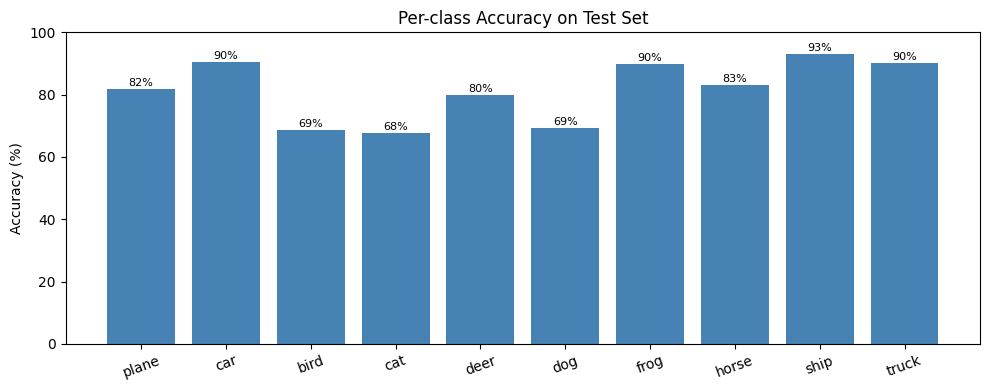

In [9]:
correct_per_class = {c: 0 for c in CLASSES}
total_per_class   = {c: 0 for c in CLASSES}

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds   = outputs.argmax(1).cpu()
        for label, pred in zip(labels, preds):
            c = CLASSES[label]
            total_per_class[c]   += 1
            correct_per_class[c] += int(pred == label)

accs = {c: correct_per_class[c] / total_per_class[c] for c in CLASSES}

plt.figure(figsize=(10, 4))
plt.bar(accs.keys(), [v * 100 for v in accs.values()], color='steelblue')
plt.ylabel('Accuracy (%)')
plt.title('Per-class Accuracy on Test Set')
plt.ylim(0, 100)
plt.xticks(rotation=20)
for i, (c, v) in enumerate(accs.items()):
    plt.text(i, v * 100 + 1, f'{v*100:.0f}%', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## 8. Save the Model

In [10]:
torch.save(model.state_dict(), 'cifar10_cnn.pth')
print('Model saved to cifar10_cnn.pth')



Model saved to cifar10_cnn.pth


---
## 💡 Ideas to Extend This Project

| Idea | What you'll learn |
|---|---|
| Add a 3rd conv block | Deeper networks, feature hierarchy |
| Try ResNet-18 (`torchvision.models`) | Transfer learning |
| Use CutMix / Mixup augmentation | Advanced regularisation |
| Plot a confusion matrix | Per-class error analysis |
| Visualise conv filters / Grad-CAM | Model interpretability |